## Setup
#### Import libraries

In [1]:
%matplotlib inline

import sys
import numpy as np
import scipy.sparse as ssp
import pandas as pd
import os
import matplotlib.pyplot as plt
#import scrublet as scr
import scanpy as sc
import time
# !!!!
# Change this path to point to folder containing helper_functions.py
sys.path.append('path/to/helper_functions.py')
import helper_functions as hf


#### Set up display parameters for nicer looking plots

In [2]:
hf.set_plot_defaults(fontsize=12)


## Load raw transcriptome data
#### Specify metadata and path to raw data

In [22]:
#Load matrices as anndata stored in a dict
D_star = {}
star_dir = 'PBMC_star/'
star_samps = ['P1', 'P2', 'P3', 'P4']

for samp in star_samps:
    D_star[samp] = sc.read_10x_mtx(star_dir + samp +'_Solo.out/GeneFull/raw/')
    sc.pp.filter_cells(D_star[samp], min_counts=10)

/opt/anaconda3/lib/python3.9/site-packages/anndata/utils.py:261: UserWarning: Suffix used (-[0-9]+) to deduplicate index values may make index values difficult to interpret. There values with a similar suffixes in the index. Consider using a different delimiter by passing `join={delimiter}`Example key collisions generated by the make_index_unique algorithm: ['SNORD116-1', 'SNORD116-2', 'SNORD116-3', 'SNORD116-4', 'SNORD116-5']
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/anndata/utils.py:261: UserWarning: Suffix used (-[0-9]+) to deduplicate index values may make index values difficult to interpret. There values with a similar suffixes in the index. Consider using a different delimiter by passing `join={delimiter}`Example key collisions generated by the make_index_unique algorithm: ['SNORD116-1', 'SNORD116-2', 'SNORD116-3', 'SNORD116-4', 'SNORD116-5']
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/anndata/utils.py:261: UserWarning: Suffix used (-[0-9]+) to d

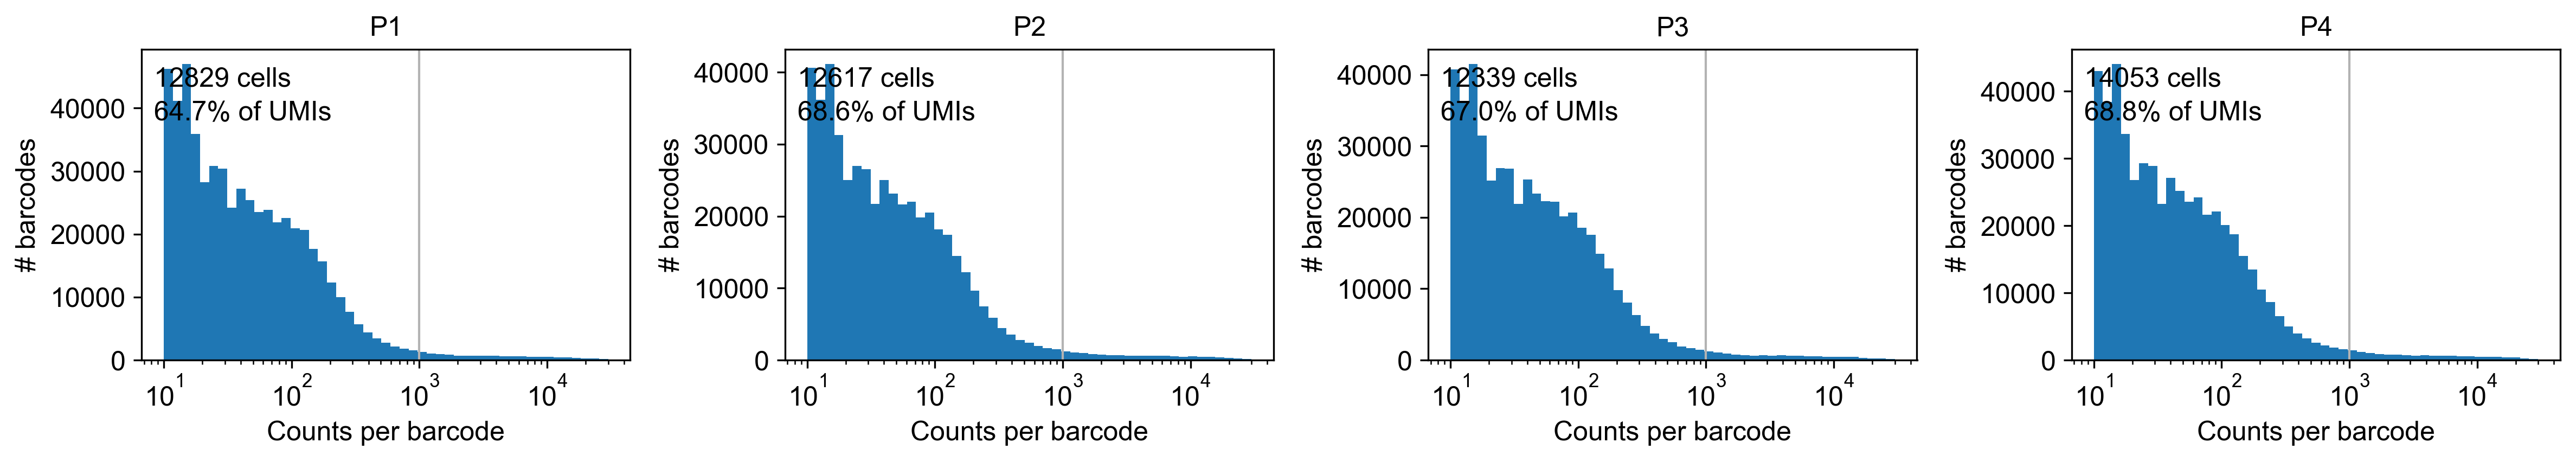

In [23]:
saving = True

# Change total count thresholds based on the histograms. 
# If a library is not included below, the default threshold is used.
#Smart-seq
D_star['P1'].uns['min_tot'] =1000
D_star['P2'].uns['min_tot'] =1000
D_star['P3'].uns['min_tot'] =1000
D_star['P4'].uns['min_tot'] =1000

############

# Start figure
fig, nrow, ncol = hf.start_subplot_figure(len(star_samps), row_height=3, n_columns=4, fig_width=16, dpi=300)

for iS,s in enumerate(star_samps):
    # Loop over each library, plotting histogram of total counts (UMIs) per cell
    
    # Set subplot
    ax = plt.subplot(nrow, ncol, iS+1)
    
    # Calculate total counts per cells (row sums of counts matrix)
    D_star[s].obs['n_counts'] = D_star[s].X.sum(1).A.squeeze()
    
    # Get minimum total counts threshold. Barcodes with 
    # total counts >= min_tot are considered real cells. 
    min_tot = D_star[s].uns['min_tot']
    
    # Plot the histogram
    hf.total_counts_histogram(D_star[s].obs['n_counts'],n_bins=50, min_bin=10, max_bin=3e4, ax=ax, counts_per_bin=False)
    ax.set_title(s, fontsize=12)
    
    xl = np.array(ax.get_xlim())
    yl = np.array(ax.get_ylim())
    ax.set_xlim(xl)
    ax.set_ylim(yl)
    
    # Plot the threshold    
    ax.plot(min_tot * np.ones(2), yl, c=.7*np.ones(3), linewidth=1)
    
    # Calculate number of barcodes and pct of UMIs passing filter and show on plot
    mask =D_star[s].obs['n_counts'].values >= min_tot
    ntot =D_star[s].shape[0]
    npass = mask.sum()
    umitot = D_star[s].obs['n_counts'].values.sum()
    umipass = D_star[s].obs['n_counts'].values[mask].sum()
    
    ax.text(xl[0] + 10**(np.log10(xl.ptp())*0.05), yl[0] + yl.ptp() * 0.88, '{} cells'.format(npass), fontsize=12)
    ax.text(xl[0] + 10**(np.log10(xl.ptp())*0.05), yl[0] + yl.ptp() * 0.77, '{:.1f}% of UMIs'.format(umipass/umitot*100), fontsize=12)
    
fig.tight_layout()

#if saving:
#    plt.savefig(f'{plot_dir}/background_filtering.pdf')


In [24]:
print('{:20s}{:>25s}{:>25s}'.format('Sample', '# barcodes pre-filter', '# barcodes post-filter'))

for s in star_samps:
    keep = D_star[s].obs['n_counts'] >= D_star[s].uns['min_tot']
    D_star[s] = D_star[s][keep].copy()
    
    n_orig = len(keep)
    n_pass = keep.sum()
    print('{:20s}{:>25}{:>25}'.format(s, n_orig, n_pass))
    
        #Store the data in dataframe
    #a = n_orig 
    #g = [[a]]
    #df2 = pd.concat([df2, pd.DataFrame(g, index = [s], columns = ['Barcodes pre-filter'])])
#df = pd.concat([df, df2], axis = 1)

Sample                  # barcodes pre-filter   # barcodes post-filter
P1                                     568047                    12829
P2                                     497906                    12617
P3                                     504200                    12339
P4                                     539446                    14053


Index(['MT-TF', 'MT-RNR1', 'MT-TV', 'MT-RNR2', 'MT-TL1', 'MT-ND1', 'MT-TI',
       'MT-TQ', 'MT-TM', 'MT-ND2', 'MT-TW', 'MT-TA', 'MT-TN', 'MT-TC', 'MT-TY',
       'MT-CO1', 'MT-TS1', 'MT-TD', 'MT-CO2', 'MT-TK', 'MT-ATP8', 'MT-ATP6',
       'MT-CO3', 'MT-TG', 'MT-ND3', 'MT-TR', 'MT-ND4L', 'MT-ND4', 'MT-TH',
       'MT-TS2', 'MT-TL2', 'MT-ND5', 'MT-ND6', 'MT-TE', 'MT-CYB', 'MT-TT',
       'MT-TP'],
      dtype='object')
Index(['MT-TF', 'MT-RNR1', 'MT-TV', 'MT-RNR2', 'MT-TL1', 'MT-ND1', 'MT-TI',
       'MT-TQ', 'MT-TM', 'MT-ND2', 'MT-TW', 'MT-TA', 'MT-TN', 'MT-TC', 'MT-TY',
       'MT-CO1', 'MT-TS1', 'MT-TD', 'MT-CO2', 'MT-TK', 'MT-ATP8', 'MT-ATP6',
       'MT-CO3', 'MT-TG', 'MT-ND3', 'MT-TR', 'MT-ND4L', 'MT-ND4', 'MT-TH',
       'MT-TS2', 'MT-TL2', 'MT-ND5', 'MT-ND6', 'MT-TE', 'MT-CYB', 'MT-TT',
       'MT-TP'],
      dtype='object')
Index(['MT-TF', 'MT-RNR1', 'MT-TV', 'MT-RNR2', 'MT-TL1', 'MT-ND1', 'MT-TI',
       'MT-TQ', 'MT-TM', 'MT-ND2', 'MT-TW', 'MT-TA', 'MT-TN', 'MT-TC', 'MT-TY',


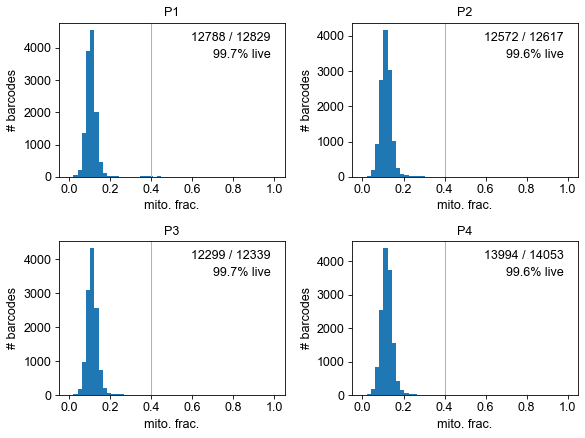

In [25]:
for iS,s in enumerate(star_samps):
    mt_ix = np.array([i for i,g in enumerate(D_star[s].var_names) if (g.startswith('mt-') or g.startswith('MT-'))], dtype=int)
    print(D_star[s].var_names[mt_ix])
saving=False

# Start figure
fig, nrow, ncol = hf.start_subplot_figure(len(star_samps), row_height=3, n_columns=2, fig_width=8, dpi=75)

for iS,s in enumerate(star_samps):
    # Loop over each library, plotting histogram of fraction of UMIs
    # coming from mitochondrial genes.
    mt_ix = np.array([i for i,g in enumerate(D_star[s].var_names) if (g.startswith('mt-') or g.startswith('MT-'))], dtype=int)


    max_mt = 0.4
    
    # Set subplot
    ax = plt.subplot(nrow, ncol, iS+1)

    # Calculate fraction of counts from mitochondrial  genes
    D_star[s].obs['mito_frac'] = D_star[s].X[:,mt_ix].sum(1).A.squeeze() / D_star[s].obs['n_counts'].values
    
    # Plot the histogram
    ax.hist(D_star[s].obs['mito_frac'], np.linspace(0, 1, 50));
    ax.set_title(s, fontsize=12)
    ax.set_xlabel('mito. frac.')
    ax.set_ylabel('# barcodes')
    
    xl = np.array([0,1])
    yl = np.array(ax.get_ylim())
    ax.set_ylim(xl)
    ax.set_ylim(yl)
    
    # Plot the threshold    
    ax.plot(max_mt * np.ones(2), yl, c=.7*np.ones(3), linewidth=1)
    
    # Calculate number of barcodes passing filter and show on plot
    ntot = len(D_star[s].obs['mito_frac'])
    npass = (D_star[s].obs['mito_frac'] <= max_mt).sum()
    ax.text(
        xl[0] + xl.ptp()*0.98, yl[0] + yl.ptp() * 0.88, 
        '{} / {}'.format(npass, ntot), fontsize=12, ha='right')
    ax.text(
        xl[0] + xl.ptp()*0.98, yl[0] + yl.ptp() * 0.77, 
        '{:.1f}% live'.format(npass/ntot*100), fontsize=12, ha='right')
    
fig.tight_layout()

if saving:
    plt.savefig(f'{plot_dir}/dead_cell_filtering.pdf')

In [26]:
print('{:20s}{:>25s}{:>25s}'.format('Sample', '# barcodes pre-filter', '# barcodes post-filter'))

for s in star_samps:
    #max_mt = 0.
    keep = D_star[s].obs['mito_frac'] <= max_mt
    D_star[s] = D_star[s][keep].copy()
    
    n_orig = len(keep)
    n_pass = keep.sum()
    print('{:20s}{:>25}{:>25}'.format(s, n_orig, n_pass))


Sample                  # barcodes pre-filter   # barcodes post-filter
P1                                      12829                    12788
P2                                      12617                    12572
P3                                      12339                    12299
P4                                      14053                    13994


In [27]:
print('{:20s}{:>5s}{:>16s}{:>16s}{:>16s}{:>16s}'.format(
    'Library', 'N', 'Mean UMI', 'Median UMI', 'Mean Genes', 'Median Genes'))

for s in star_samps:
    tc = D_star[s].obs['n_counts'].values
    tg = (D_star[s].X>0).sum(1).A.squeeze()
    print(f'{s:20s}{D_star[s].shape[0]:5}{np.mean(tc):16.0f}{np.median(tc):16.0f}{np.mean(tg):16.0f}{np.median(tg):16.0f}')

Library                 N        Mean UMI      Median UMI      Mean Genes    Median Genes
P1                  12788            6126            3425            2435            1990
P2                  12572            6305            3338            2412            1928
P3                  12299            6133            3362            2379            1929
P4                  13994            6287            3398            2405            1942


# Merged analysis
Next, we merge all the samples that came as separate libraries into a single matrix with batch_key "sample"

In [49]:
#Initial dict
D_batch = {}

#Samples to merge
samps_merge_dict = {
   'PBMC':['P1', 'P2', 'P3', 'P4'],
}

#Now merge
for s, samps_merge in samps_merge_dict.items():
    print(f'___________________\nProcessing {s}')
    D_batch[s] = sc.AnnData.concatenate(
        *[D_star[s] for s in samps_merge], 
        batch_categories=samps_merge,
        batch_key='sample'
        )




___________________
Processing PBMC


/var/folders/xk/8j_p5ynd0034x23z5b59nccr0000gq/T/ipykernel_34971/527101972.py:10: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  D_batch[s] = sc.AnnData.concatenate(


## Process samples

In [50]:
#Let's make a copy before processing
adata = D_batch['PBMC'].copy()

#Normalize the counts
sc.pp.normalize_total(adata, target_sum=1e4)

In [291]:
#Run scrublet to remove doublets
sc.external.pp.scrublet(adata)

/opt/anaconda3/lib/python3.9/site-packages/scanpy/preprocessing/_normalization.py:170: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


Automatically set threshold at doublet score = 0.17
Detected doublet rate = 6.9%
Estimated detectable doublet fraction = 62.3%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 11.1%


In [292]:
#Now remove doublets
adata = adata[~adata.obs['predicted_doublet']]

In [293]:
#Log the data
sc.pp.log1p(adata)

/opt/anaconda3/lib/python3.9/site-packages/scanpy/preprocessing/_simple.py:373: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


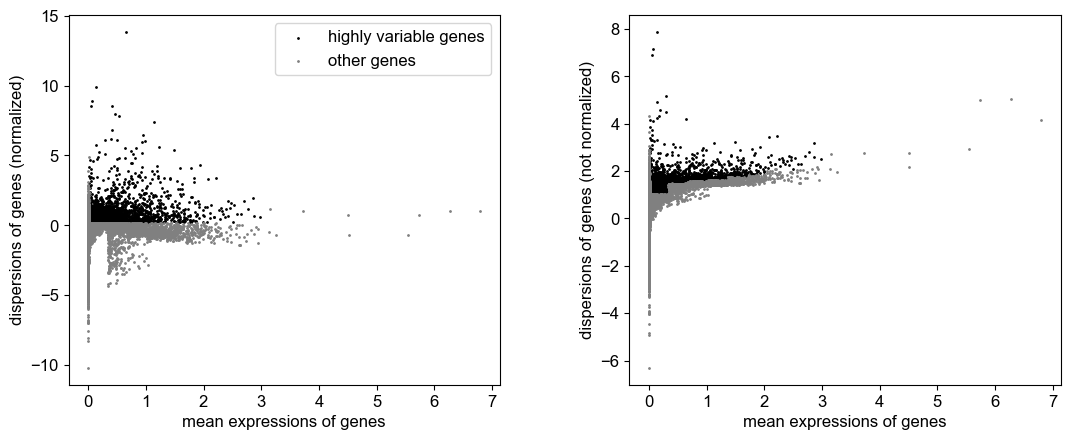

/opt/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:1235: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  df[key] = c


In [294]:
#Indentify highly variable genes for simple pre-processing
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.2)
sc.pl.highly_variable_genes(adata) # scanpy generates the filename automatically

# Save raw expression values before variable gene subset
adata.raw = adata

#Update the adata
adata = adata[:, adata.var.highly_variable]
sc.pp.regress_out(adata, ['n_counts'])
sc.pp.scale(adata, max_value=10)

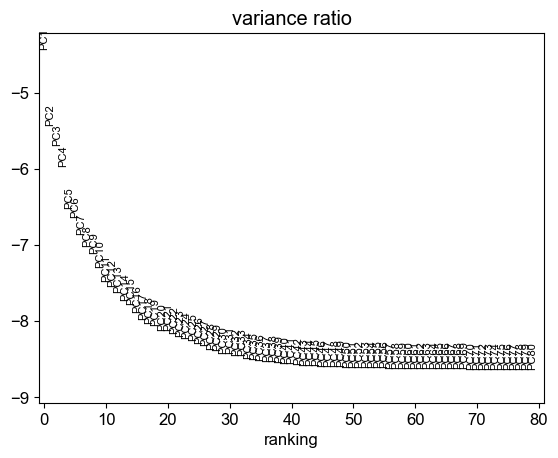

In [295]:
sc.tl.pca(adata, n_comps=80, svd_solver='arpack')
sc.pl.pca_variance_ratio(adata, log=True, n_pcs=80) # scanpy generates the filename automatically

In [298]:
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=40)

/opt/anaconda3/lib/python3.9/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/opt/anaconda3/lib/python3.9/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/opt/anaconda3/lib/python3.9/site-packages/umap/distances.py:1086: NumbaDeprecationWarning: The 'nopython' keywo

In [299]:
sc.tl.umap(adata, min_dist=0.4, spread=1, random_state=3)


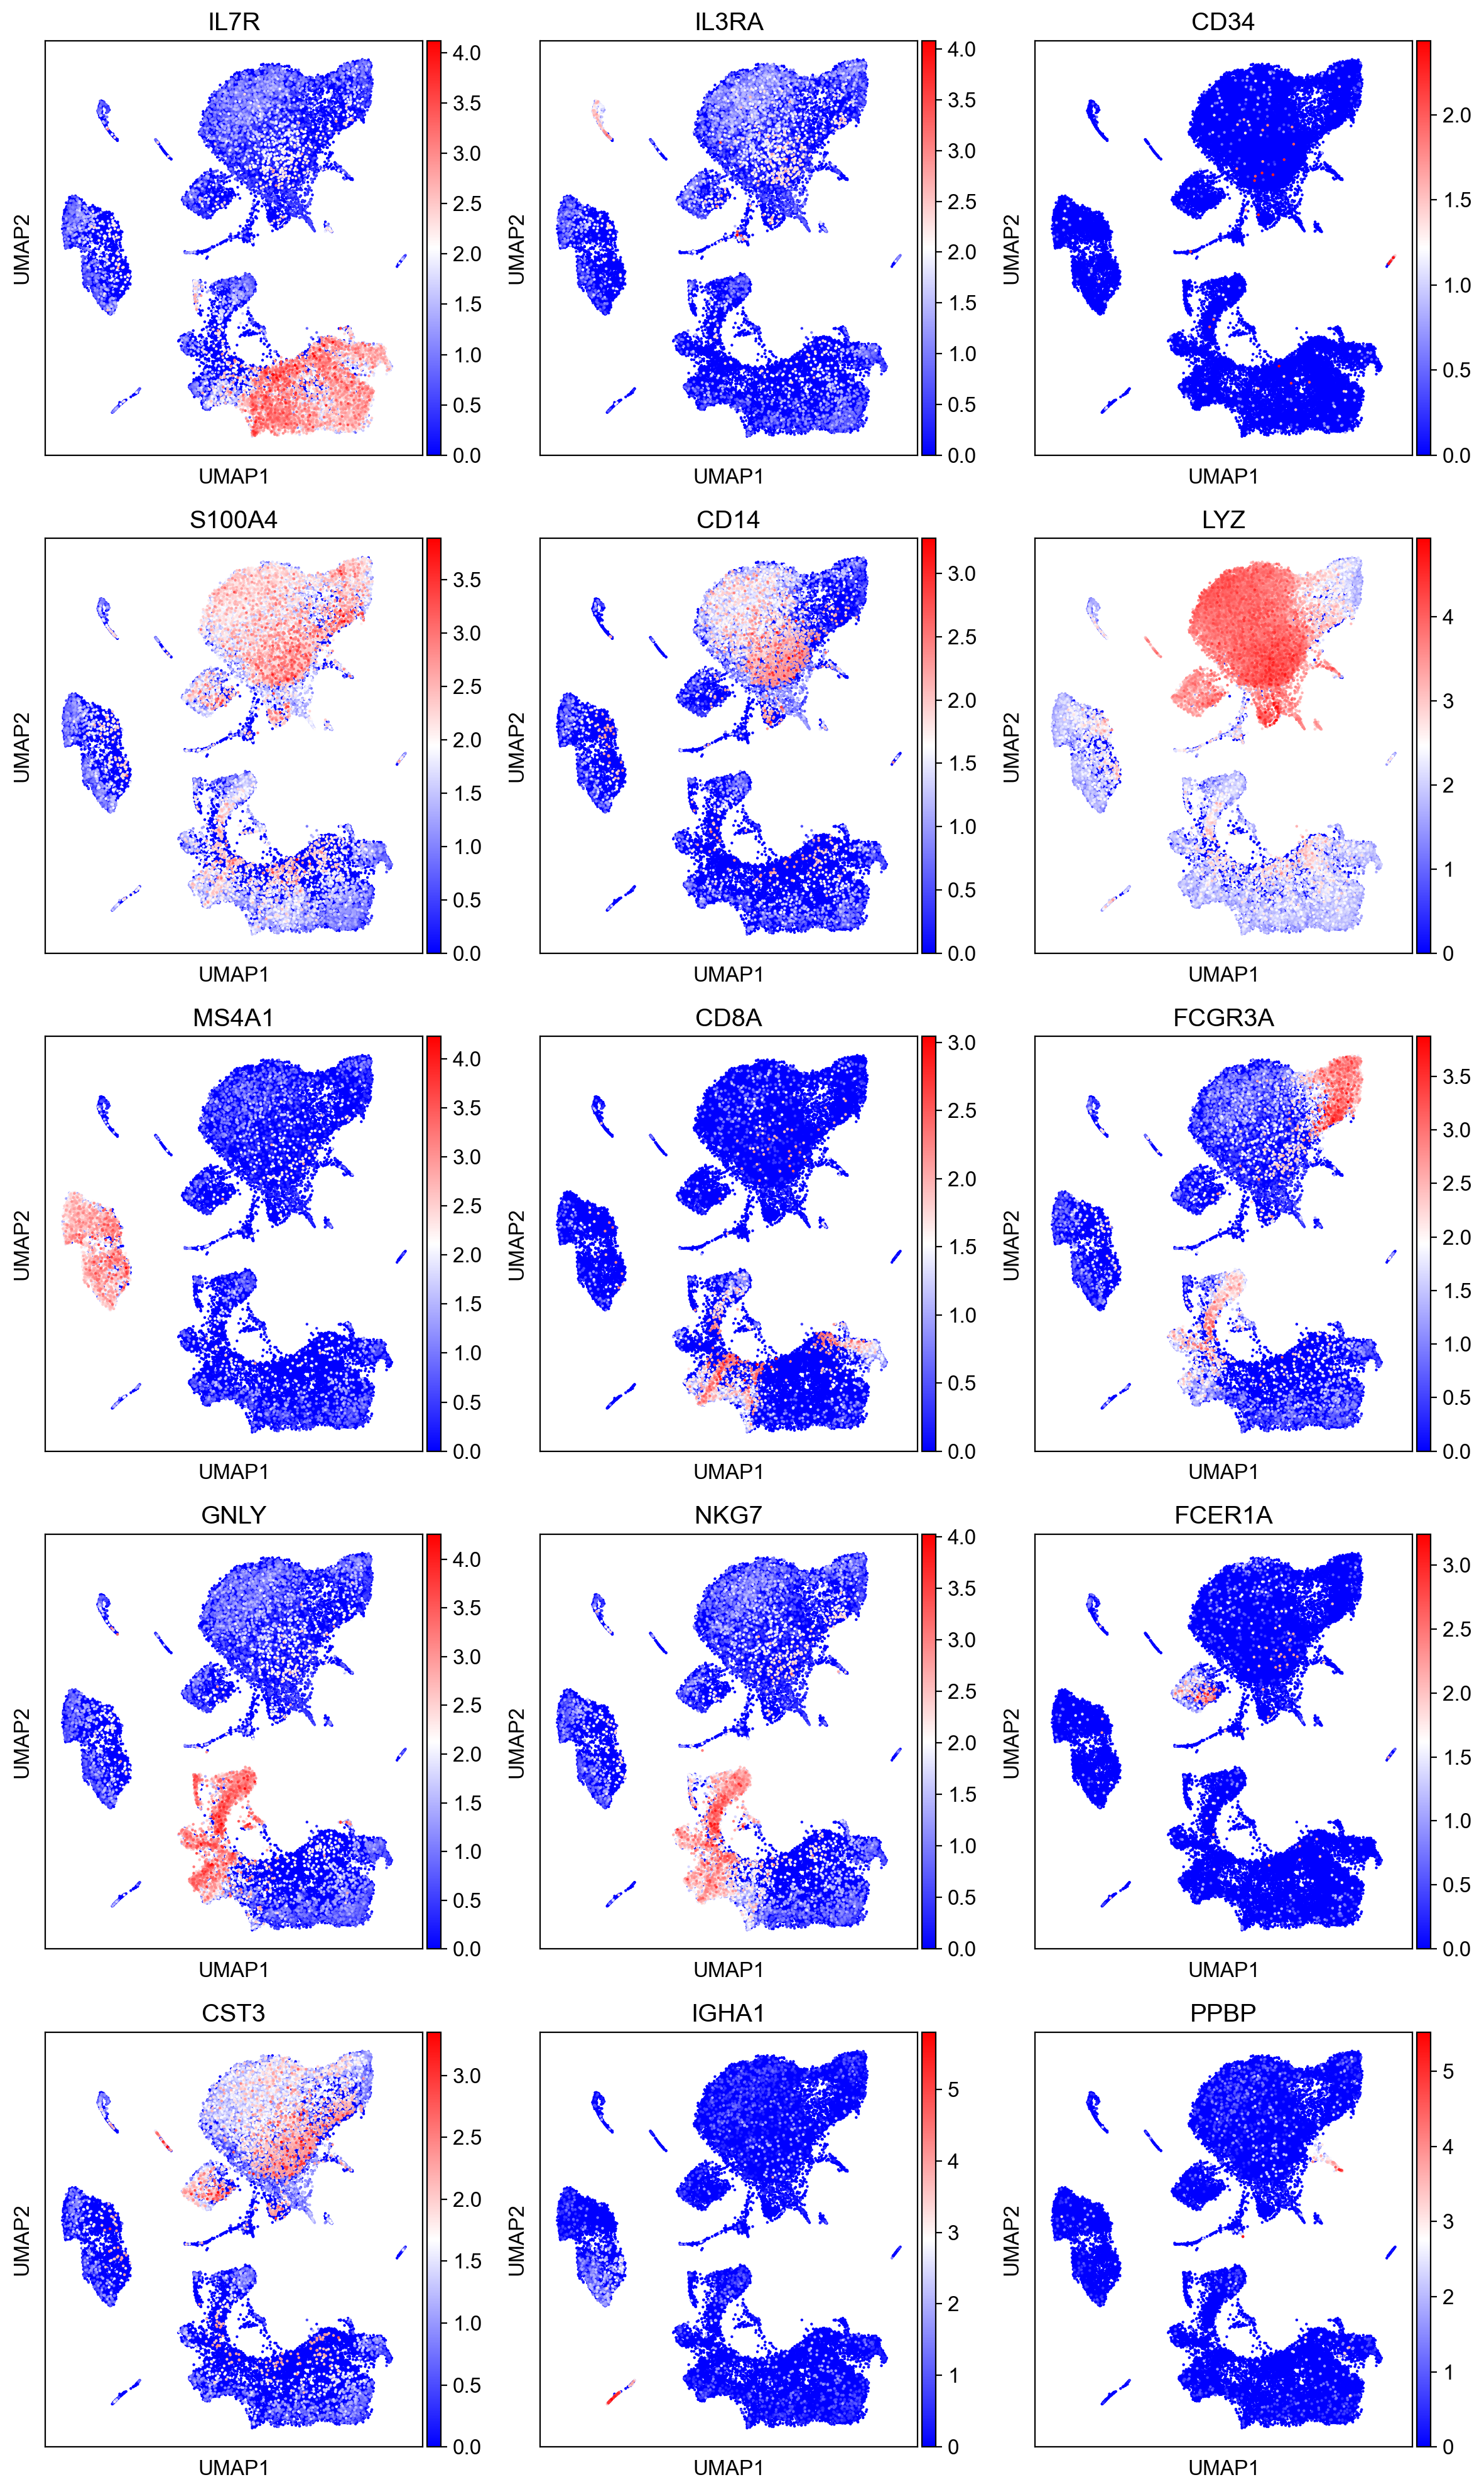

In [300]:
#Let's plot some example genes
gene_list = ['IL7R', 'IL3RA','CD34', 'S100A4', 'CD14', 'LYZ', 'MS4A1', 'CD8A',
    'FCGR3A', 'GNLY', 'NKG7', 'FCER1A', 'CST3', 'IGHA1', 'PPBP']

#gene_list = ['IL7R', 'MS4A1', 'NKG7', 'CD8A', 'IL4R', 'AIM2', 'IL32']
# Create subplot grid
n_states = len(gene_list)
n_cols = 3  # The number of columns for the subplot grid
n_rows = np.ceil(n_states / n_cols).astype(int)
fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 4), dpi = 200)
axs = axs.flatten()  # Flatten the axis array for easy iteration


for i, g in enumerate(gene_list):
    ax = axs[i]
    sc.pl.umap(adata, ax=ax,size=10, color=g,color_map='bwr',vmin=0,show=False)

# Turn off axes for any unused subplots
for i in range(len(gene_list), len(axs)):
    axs[i].axis('off')
    
plt.tight_layout()
plt.show()

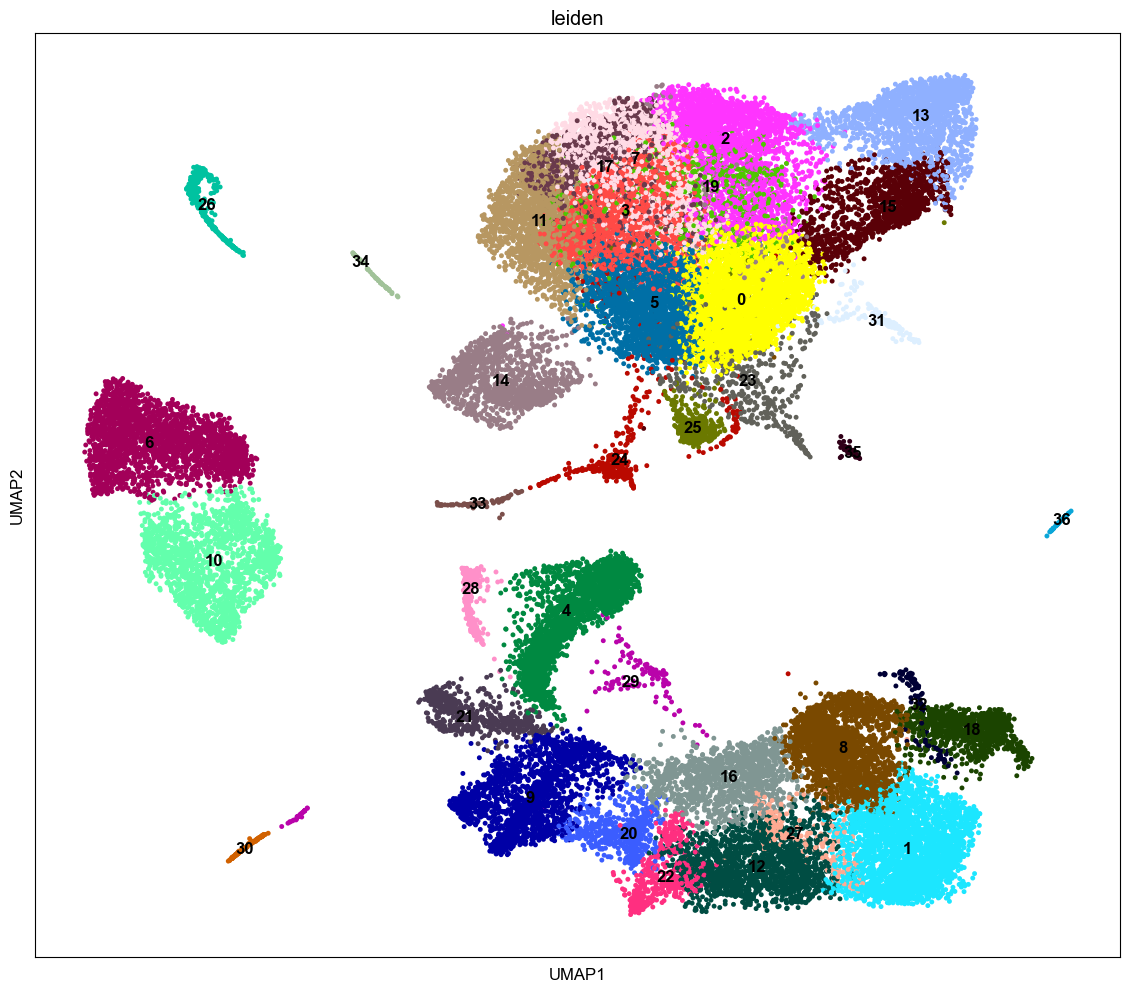

In [303]:
# Plot UMAP:
fig, ax = plt.subplots(figsize=(14, 12))  # Adjust the figure size as needed
sc.tl.leiden(adata, resolution=2)
sc.pl.umap(adata, ax=ax,size=50, color='leiden',legend_loc='on data')

Coarse cell-type labeling based on gene expression. Will dive deeper later

In [433]:
labels = {'0':"CD14 Monocytes",
 '1':"Naive/Memory CD4",
 '2':"CD14 Monocytes",
 '3':"CD14 Monocytes",
 '4':"NK 3",
 '5':"CD14 Monocytes",       
 '6':"Naive B",
 '7':"CD14 Monocytes",
 '8':"Naive/Memory CD4",
 '9':"Cytotoxic CD8",
 '10':"Memory B",
 '11':"CD14 Monocytes",
 '12':"Effector CD4 cells",
 '13':"CD16 Monocytes",
 '14':"cDC2",
 '15':"CD16 Monocytes",
 '16':"Effector CD4 cells",
 '17':"CD14 Monocytes",
 '18':"Naive/Memory CD8",
 '19':"CD14 Monocytes",
 '20':"Cytotoxic CD8",
 '21':"NK 1",
 '22':"MAIT T-cells",
 '23':"CD14 Monocytes",
 '24':'Other',
 '25':"CD14 Monocytes",
 '26':'pDC',
 '27':'Effector CD4 cells',
 '28':'NK 2',
 '29':'Proliferating',
 '30':"Plasma cells",
 '31':'Megakaryocytes',
 '32':"Tregs",
 '33':'Other',
 '34':'cDC1',
 '35':"Other",
 '36':'HPCs',
}

In [434]:
adata.obs['cell_type'] = (
    adata.obs['leiden']
    .map(labels)
    .astype('category')
)


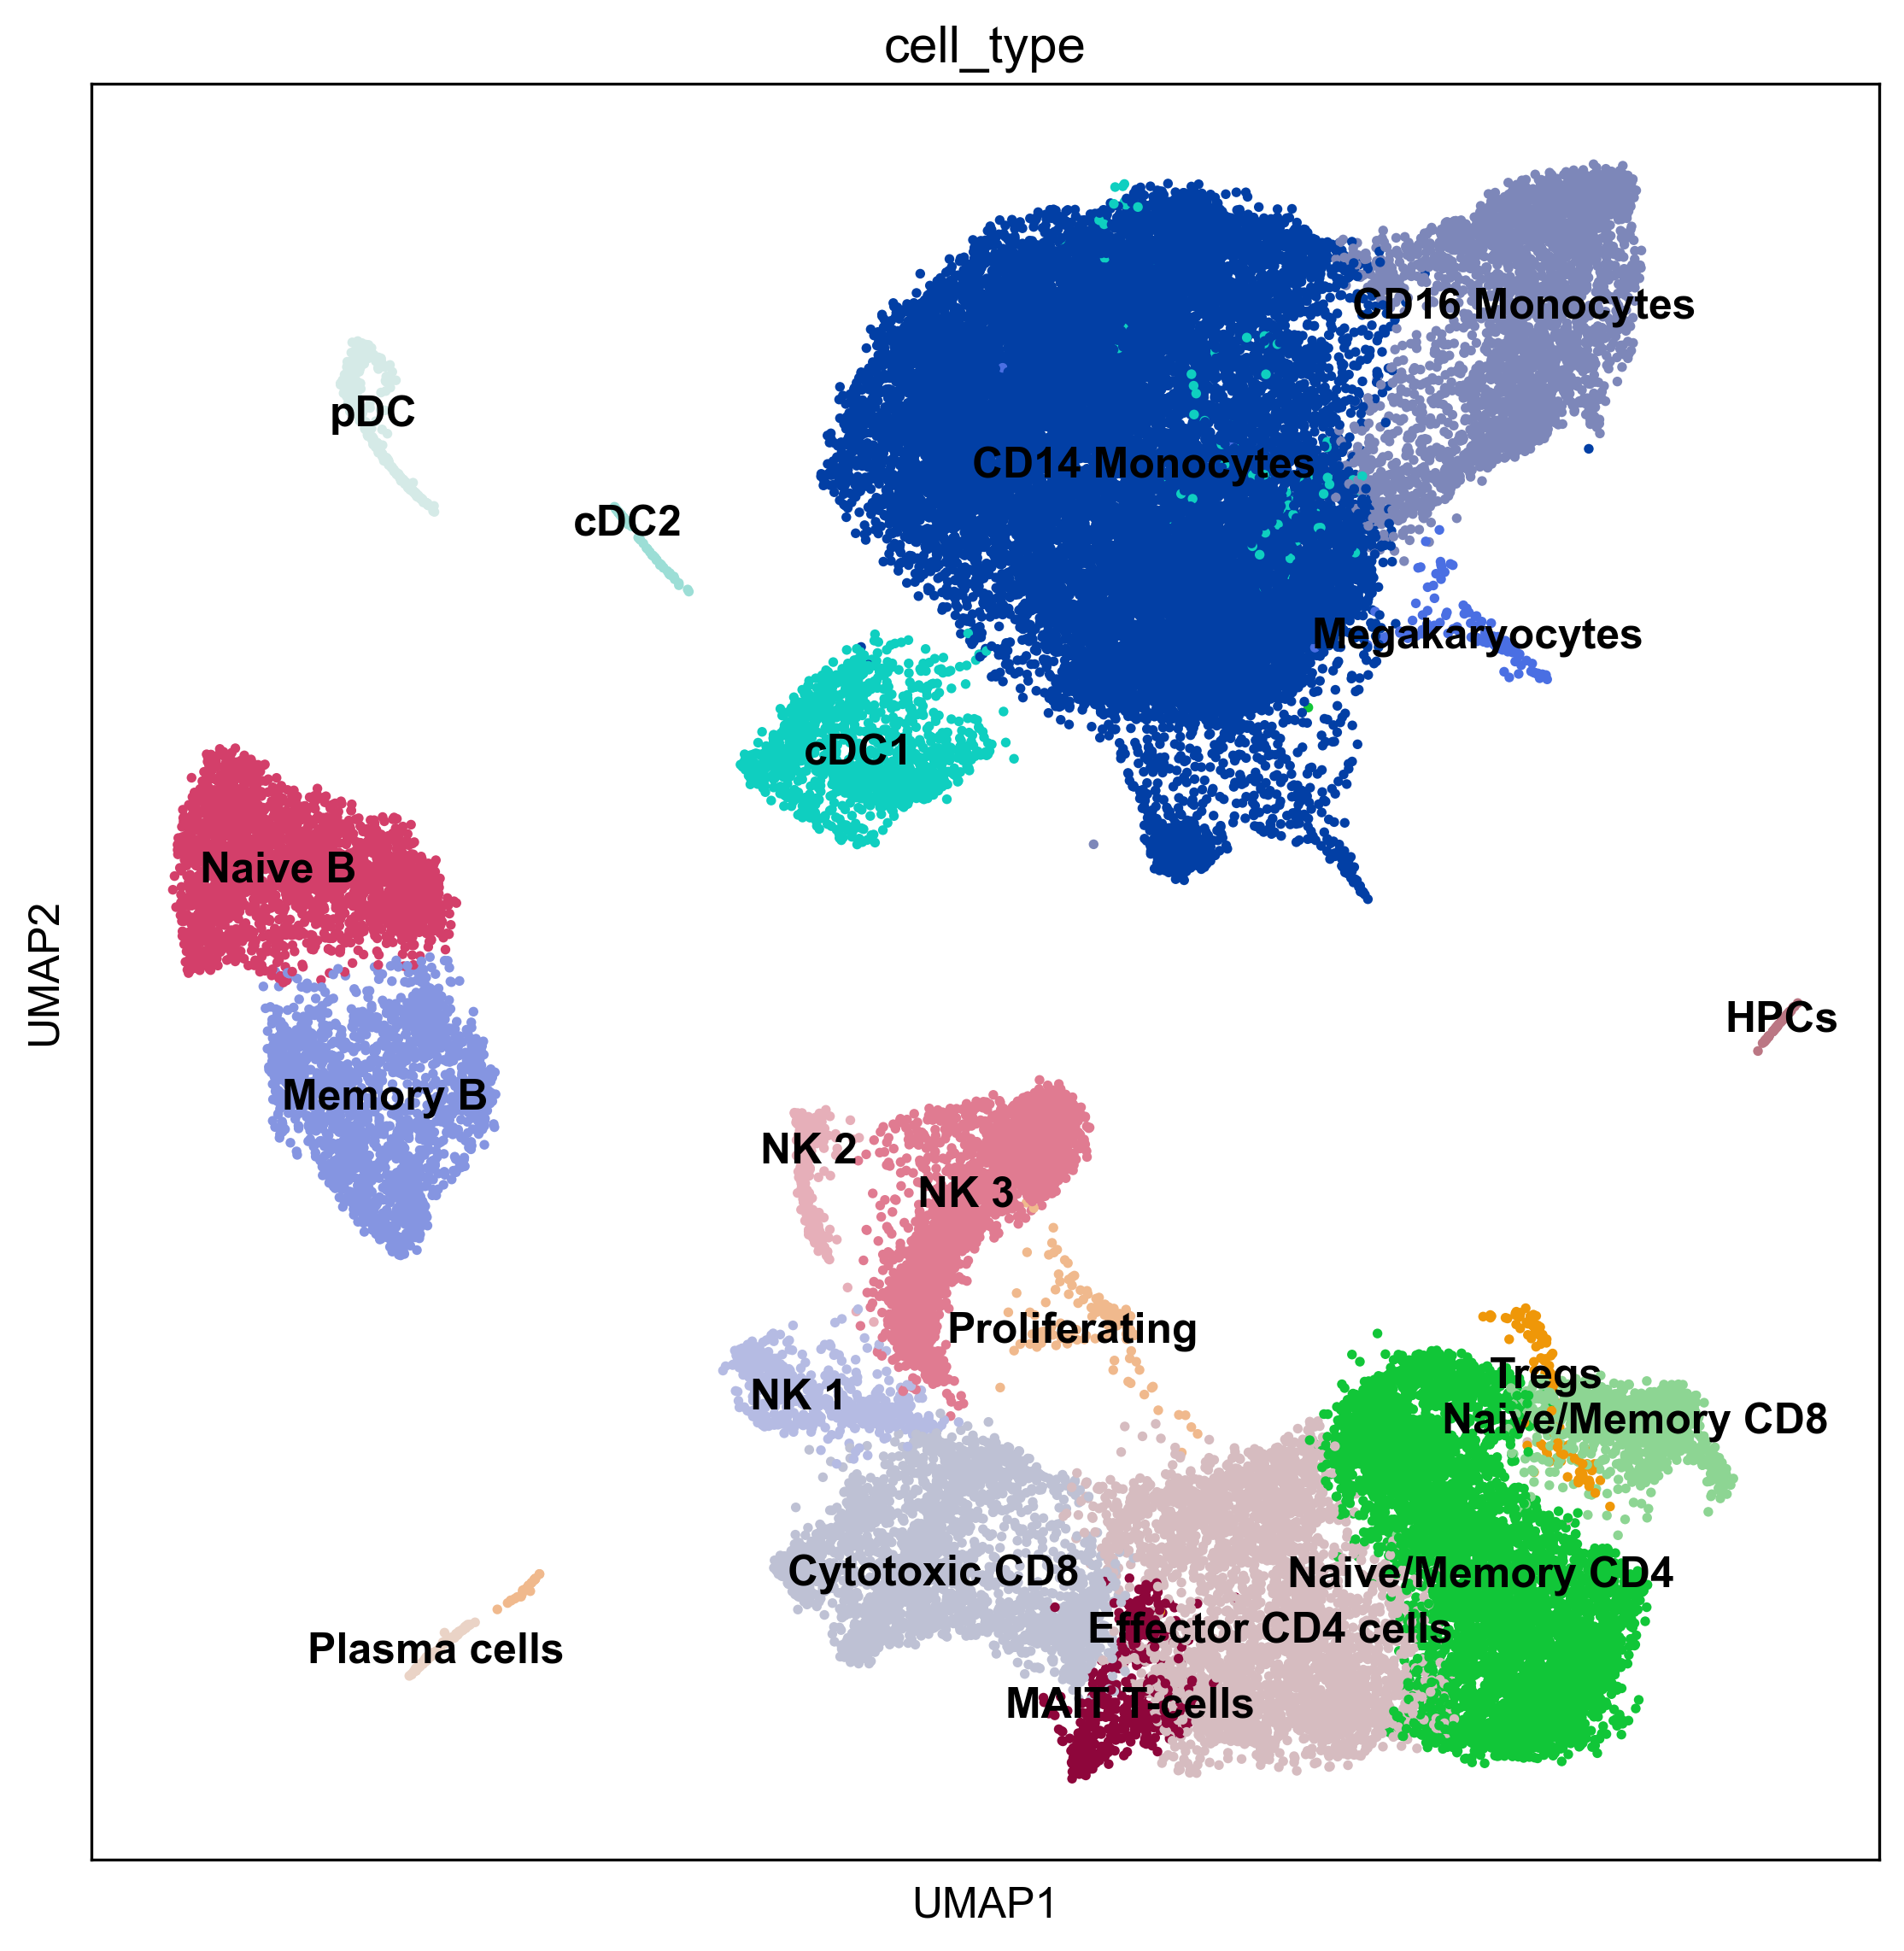

In [449]:
fig, ax = plt.subplots(figsize=(9, 9), dpi= 300)  # Adjust the figure size as needed
sc.pl.umap(adata[~(adata.obs['cell_type']=='Other').values], ax=ax,size=30, color='cell_type',legend_loc='on data', use_raw=False, edges_color='Black')

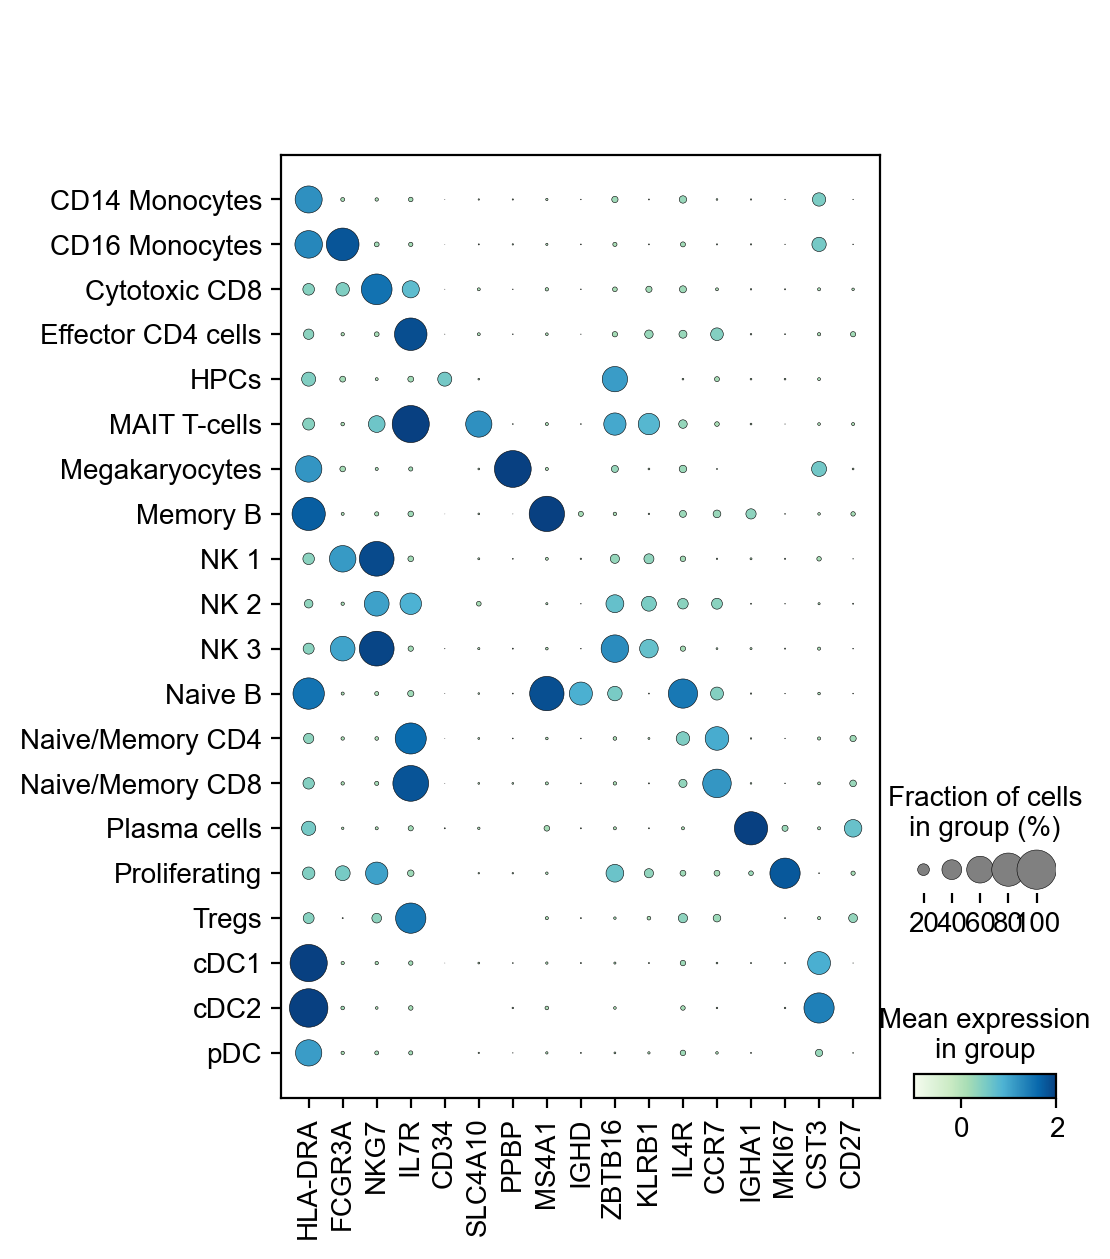

<Figure size 640x480 with 0 Axes>

In [661]:
fig, ax = plt.subplots(figsize= (5,7), dpi = 200)
marker_genes = ['IL7R', 'NKG7', 'KLRB1', 'CD34', 'MS4A1','ZBTB16', 'TRDC', 'TRGC1', 'TRGC2', 'TRGV9']
#marker_genes = ['CD8A', 'IL7R','CD34', 'CD14',
#    'FCGR3A', 'GNLY', 'NKG7', 'FCER1A', 'CST3','IL3RA',  'PPBP', 'TRDC', 'TRGC1', 'TRGC2', 'SLC4A10', 'IGHA1', 'JCHAIN', 'MS4A1', 'ZBTB16']
marker_genes = ['HLA-DRA', 'FCGR3A', 'NKG7', 'IL7R', 'CD34','SLC4A10', 'PPBP', 'MS4A1','IGHD', 'ZBTB16', 'KLRB1', 'IL4R', 'CCR7', 'IGHA1','MKI67', 'CST3', 'CD27']
#marker_genes = ['CD14']az
sc.pl.dotplot(adata[~(adata.obs['cell_type']=='Other').values], marker_genes, groupby="cell_type",vmin = -1, vmax=2, ax=ax, cmap='GnBu', expression_cutoff=1);
plt.tight_layout()
#plt.savefig()

Save processed matrices for deeper analys

In [868]:
adata.write_h5ad('PBMCs_processed.h5ad', compression='gzip')

#Saving adata without the unkown Other (most likely doublet) population
adata[~(adata.obs['cell_type']=='Other').values].write_h5ad('PBMCs_processed_noOther.h5ad', compression='gzip')

## Further analysis

In [30]:
#Load the processed data from before
adata = sc.read_h5ad('PBMCs_processed_noOther.h5ad')

Re-Label the cells 

In [31]:
#list to reorder and rename matrix rows 

new_labels_dict = {'HPCs':'HPC', 
                  'Megakaryocytes': 'Platelet',
                  'CD14 Monocytes':'Mono. CD14',
                  'CD16 Monocytes':'Mono. CD16',
                  'cDC2':'cDC-1', # THESE APPEAR MISLABELED
                  'cDC1':'cDC-2', # THESE APPEAR MISLABELED - SWITCHED, BASED ON IRF8 AND OTHER MARKERS
                  'pDC':'pDC', 
                  'Naive B':'Naive B', 
                  'Memory B':'Mem. B', 
                  'Plasma cells':'Plasmoblast',  # Not plasma cells
                  'Proliferating':'T$_{cyc.}$',
                  'Tregs':'CD8 T$_{Naive/Mem}^{Helios+}$', #Not T_regs!
                  'Effector CD4 cells':'CD4 T$_{eff}$', 
                  'Naive/Memory CD4':'CD4 T$_{Naive/Mem}$',
                  'Naive/Memory CD8':'CD8 T$_{Naive/Mem}$', 
                  'Cytotoxic CD8':'CD8 T$_{cyt}$',
                  'MAIT T-cells':'T$_{MAIT}$',
                  'NK 1':'NK 1',
                  'NK 2':'NK 2', 
                  'NK 3':'NK 3'
                 }

coarse_labels_dict = {'HPCs':'HPC', 
                  'Megakaryocytes': 'Platelet',
                  'CD14 Monocytes':'Mono. CD14',
                  'CD16 Monocytes':'Mono. CD16',
                  'cDC2':'cDC1', # THESE APPEAR MISLABELED
                  'cDC1':'cDC2', # THESE APPEAR MISLABELED
                  'pDC':'pDC', 
                  'Naive B':'B', 
                  'Memory B':'B', 
                  'Plasma cells':'Plasmoblast',  # Not plasma cells
                  'Proliferating':'T',
                  'Tregs':'T', #Not T_regs!
                  'Effector CD4 cells':'T', 
                  'Naive/Memory CD4':'T',
                  'Naive/Memory CD8':'T', 
                  'Cytotoxic CD8':'T',
                  'MAIT T-cells':'T',
                  'NK 1':'NK',
                  'NK 2':'NK', 
                  'NK 3':'NK'
                 }

if 'cell_type_old' not in adata.obs.columns:
    adata.obs['cell_type_old'] = adata.obs['cell_type']
    
adata.obs['cell_type_major'] = [coarse_labels_dict[s] for s in adata.obs['cell_type_old']]
adata.obs['cell_type'] = [new_labels_dict[s] for s in adata.obs['cell_type_old']]


In [32]:
# Recover raw X
# Create a new AnnData object with raw dimensions
full_adata = sc.AnnData(
    X=adata.raw.X.copy(),
    obs=adata.obs,
    var=adata.raw.var
)


In [33]:
# Create cross-tabulation of raw counts
crosstab = pd.crosstab(
    adata.obs['leiden'], 
    adata.obs['cell_type']
)

# For each leiden cluster, find the majority cell type
leiden_to_celltype = {}
for leiden in crosstab.index:
    majority_celltype = crosstab.loc[leiden].idxmax()
    majority_fraction = crosstab.loc[leiden].max() / crosstab.loc[leiden].sum()
    leiden_to_celltype[leiden] = majority_celltype
    print(f"Leiden {leiden}: {majority_celltype} ({majority_fraction:.1%})")

# Create new column based on the mapping
adata.obs['cell_type_cg'] = adata.obs['leiden'].map(leiden_to_celltype)

# Verify the mapping worked
print("\nNumber of cells in each cell_type_cg:")
print(adata.obs['cell_type_cg'].value_counts())

# Optional: Compare with original cell types
#print("\nCrosstab of original cell_type vs cell_type_cg:")
#print(pd.crosstab(adata.obs['cell_type'], adata.obs['cell_type_cg']))

Leiden 0: Mono. CD14 (100.0%)
Leiden 1: CD4 T$_{Naive/Mem}$ (100.0%)
Leiden 2: Mono. CD14 (100.0%)
Leiden 3: Mono. CD14 (100.0%)
Leiden 4: NK 3 (100.0%)
Leiden 5: Mono. CD14 (100.0%)
Leiden 6: Naive B (100.0%)
Leiden 7: Mono. CD14 (100.0%)
Leiden 8: CD4 T$_{Naive/Mem}$ (100.0%)
Leiden 9: CD8 T$_{cyt}$ (100.0%)
Leiden 10: Mem. B (100.0%)
Leiden 11: Mono. CD14 (100.0%)
Leiden 12: CD4 T$_{eff}$ (100.0%)
Leiden 13: Mono. CD16 (100.0%)
Leiden 14: cDC-2 (100.0%)
Leiden 15: Mono. CD16 (100.0%)
Leiden 16: CD4 T$_{eff}$ (100.0%)
Leiden 17: Mono. CD14 (100.0%)
Leiden 18: CD8 T$_{Naive/Mem}$ (100.0%)
Leiden 19: Mono. CD14 (100.0%)
Leiden 20: CD8 T$_{cyt}$ (100.0%)
Leiden 21: NK 1 (100.0%)
Leiden 22: T$_{MAIT}$ (100.0%)
Leiden 23: Mono. CD14 (100.0%)
Leiden 25: Mono. CD14 (100.0%)
Leiden 26: pDC (100.0%)
Leiden 27: CD4 T$_{eff}$ (100.0%)
Leiden 28: NK 2 (100.0%)
Leiden 29: T$_{cyc.}$ (100.0%)
Leiden 30: Plasmoblast (100.0%)
Leiden 31: Platelet (100.0%)
Leiden 32: CD8 T$_{Naive/Mem}^{Helios+}$ (100

In [34]:
# Update major labels to include B subsets
adata.obs['cell_type_major'] = adata.obs['cell_type_major'].astype(str)
B_cells = adata[adata.obs['cell_type_major']=='B'].obs_names
adata.obs.loc[B_cells, 'cell_type_major'] = adata.obs.loc[B_cells, 'cell_type_cg'].astype(str)
adata.obs['cell_type_major'] = adata.obs['cell_type_major'].astype('category')



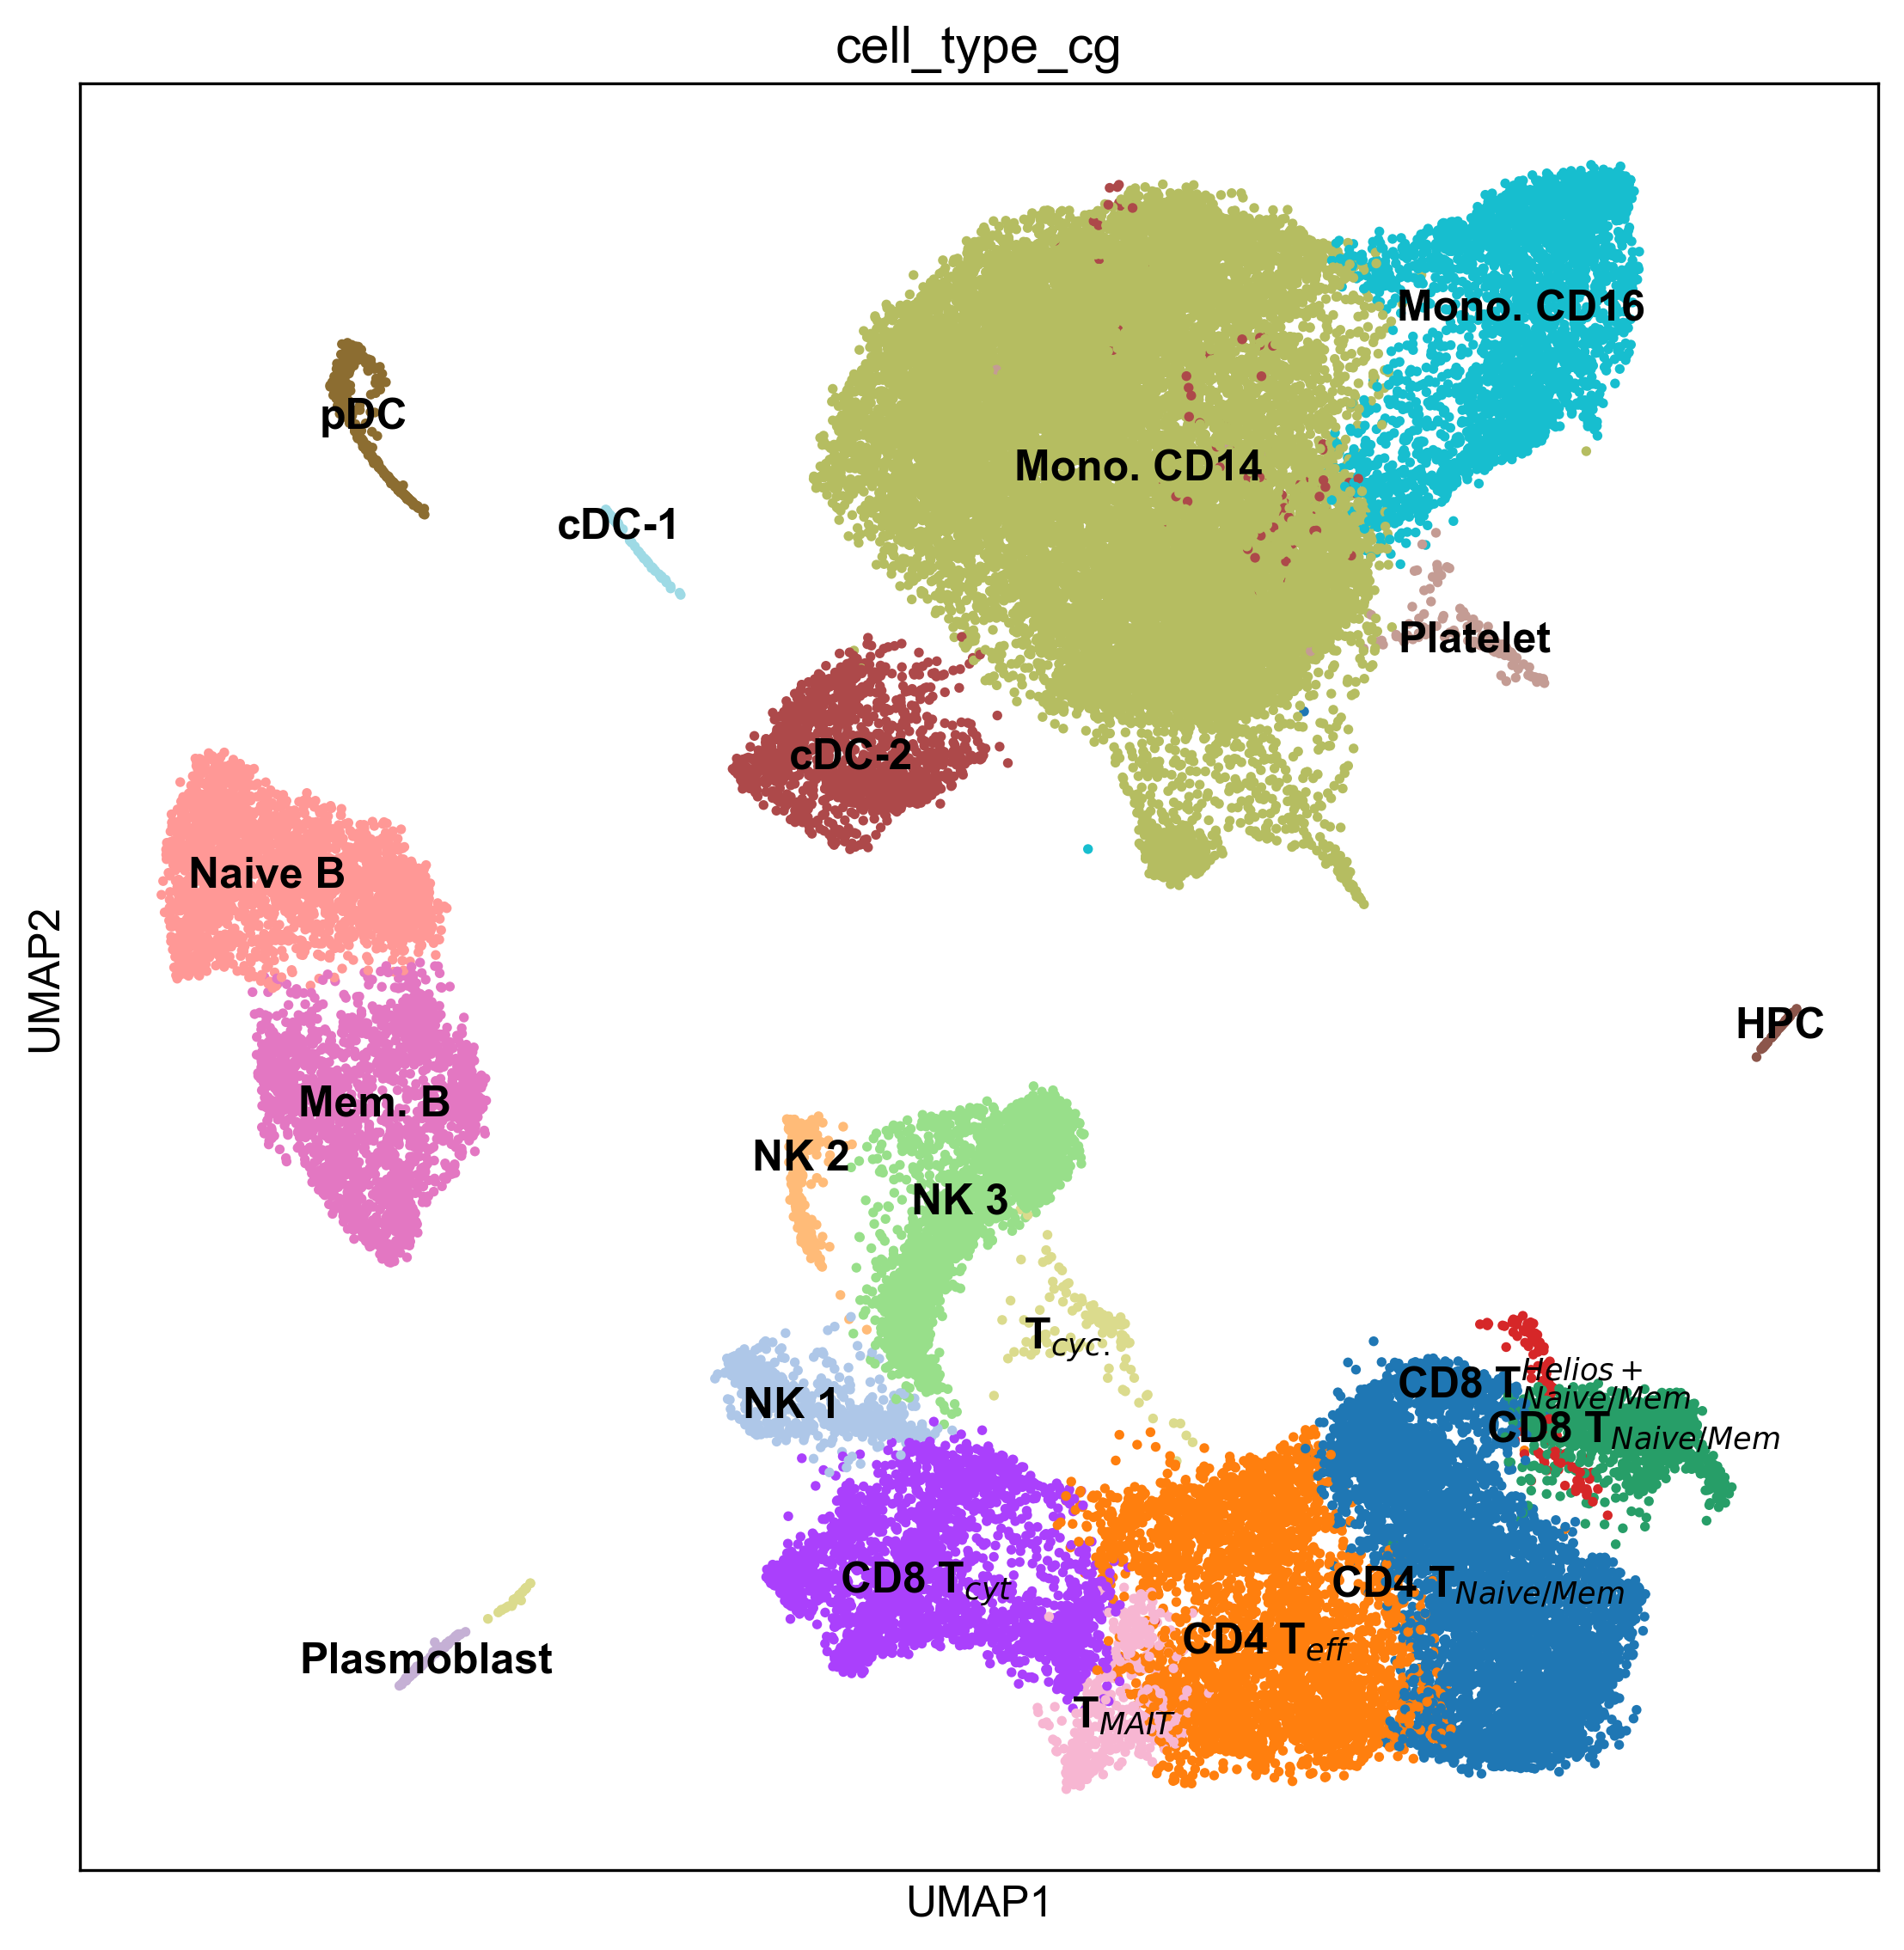

In [35]:
fig, ax = plt.subplots(figsize=(9, 9), dpi= 300)  # Adjust the figure size as needed
sc.pl.umap(adata, ax=ax,size=30, color='cell_type_cg',legend_loc='on data', use_raw=False, edges_color='Black')

In [36]:
# Carve out T/NK and save
full_adata.obs = adata.obs
adata_TNK = full_adata[full_adata.obs['cell_type_major'].isin(['T', 'NK'])].copy()
#adata_TNK.write_h5ad('adata_TNK.h5ad')

In [37]:
# Also, save the full adata matrix:
#full_adata.write_h5ad('adata_full.h5ad')

## TNK cells more detailed processing

In [38]:
# Calculate QC metrics
sc.pp.calculate_qc_metrics(adata_TNK, inplace=True)

# Identify highly variable genes
# Inheriting highly-variable genes from pre-processing
#sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor='seurat_v3_paper')

# Normalize total counts per cell
sc.pp.normalize_total(adata_TNK, target_sum=1e4)

# Tweak highly-variable:
#adata.var['highly_variable'] = adata.var['highly_variable'] & (np.array(adata.X.max(axis=0).todense())[0]>=15)

adata_TNK_unscaled = adata_TNK.copy()
# Log transform
#sc.pp.log1p(adata, base=10)

# Scale data - not scaling now
sc.pp.scale(adata_TNK, max_value=10)



In [39]:
print("Running PCA...")
# Run PCA
sc.tl.pca(adata_TNK, n_comps=40,use_highly_variable=True)

print("Computing neighborhood graph...")
# Compute neighborhood graph
sc.pp.neighbors(adata_TNK, n_neighbors=10, n_pcs=40)

Running PCA...


/opt/anaconda3/lib/python3.9/site-packages/scanpy/preprocessing/_pca.py:377: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)


Computing neighborhood graph...


In [40]:
print("Running UMAP...")
# Run UMAP
sc.tl.umap(adata_TNK,min_dist=0.2,spread=1.0) #, maxiter=1000

Running UMAP...


In [41]:
print("Running Leiden clustering...")
# Run Leiden clustering
sc.tl.leiden(adata_TNK,
             resolution=1.5,
             key_added='leiden')


Running Leiden clustering...


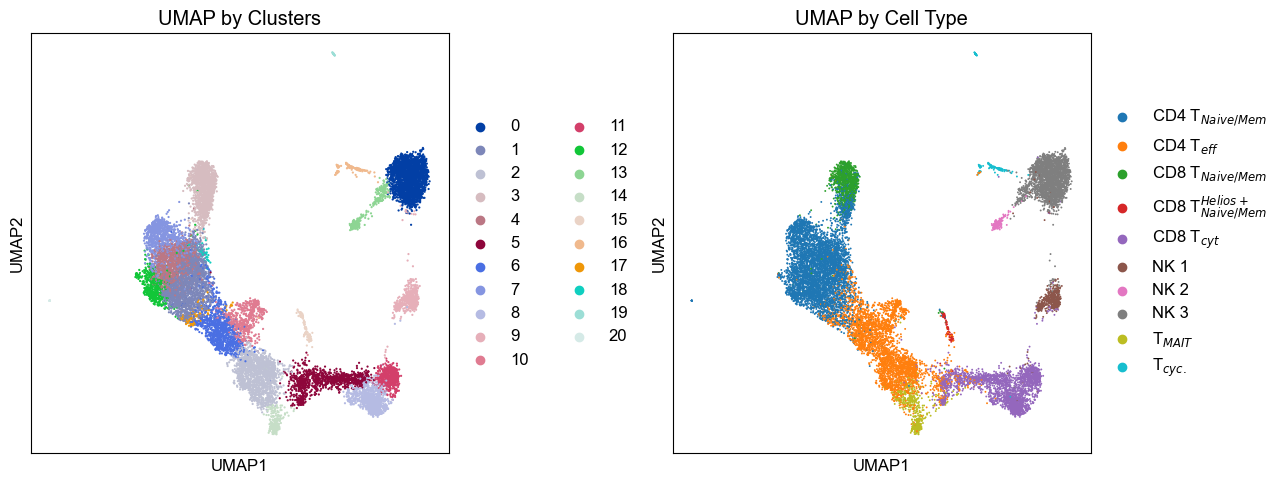

In [42]:
# Set figure size for all plots
sc.settings.figsize = (10, 10)

# Create a figure with multiple subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Plot UMAP with clusters
sc.pl.umap(adata_TNK, color='leiden', ax=ax1, size=10, show=False, title='UMAP by Clusters')

# Plot UMAP with cell types
sc.pl.umap(adata_TNK, color='cell_type', ax=ax2, show=False, title='UMAP by Cell Type')

plt.tight_layout()
plt.show()

plt.close()


In [43]:
# Create cross-tabulation of raw counts
crosstab = pd.crosstab(
    adata_TNK.obs['leiden'], 
    adata_TNK.obs['cell_type']
)

# For each leiden cluster, find the majority cell type
leiden_to_celltype = {}
for leiden in crosstab.index:
    majority_celltype = crosstab.loc[leiden].idxmax()
    majority_fraction = crosstab.loc[leiden].max() / crosstab.loc[leiden].sum()
    leiden_to_celltype[leiden] = majority_celltype
    print(f"Leiden {leiden}: {majority_celltype} ({majority_fraction:.1%})")

# Create new column based on the mapping
adata_TNK.obs['cell_type_cg'] = adata_TNK.obs['leiden'].map(leiden_to_celltype)



Leiden 0: NK 3 (99.2%)
Leiden 1: CD4 T$_{Naive/Mem}$ (92.9%)
Leiden 2: CD4 T$_{eff}$ (86.0%)
Leiden 3: CD8 T$_{Naive/Mem}$ (70.2%)
Leiden 4: CD4 T$_{Naive/Mem}$ (99.4%)
Leiden 5: CD8 T$_{cyt}$ (78.4%)
Leiden 6: CD4 T$_{eff}$ (83.2%)
Leiden 7: CD4 T$_{Naive/Mem}$ (99.3%)
Leiden 8: CD8 T$_{cyt}$ (99.0%)
Leiden 9: NK 1 (89.3%)
Leiden 10: CD4 T$_{eff}$ (98.4%)
Leiden 11: CD8 T$_{cyt}$ (98.3%)
Leiden 12: CD4 T$_{Naive/Mem}$ (98.1%)
Leiden 13: NK 2 (62.8%)
Leiden 14: T$_{MAIT}$ (89.9%)
Leiden 15: CD8 T$_{Naive/Mem}^{Helios+}$ (73.7%)
Leiden 16: T$_{cyc.}$ (92.2%)
Leiden 17: CD4 T$_{eff}$ (81.9%)
Leiden 18: CD4 T$_{Naive/Mem}$ (97.9%)
Leiden 19: T$_{cyc.}$ (100.0%)
Leiden 20: CD4 T$_{Naive/Mem}$ (100.0%)


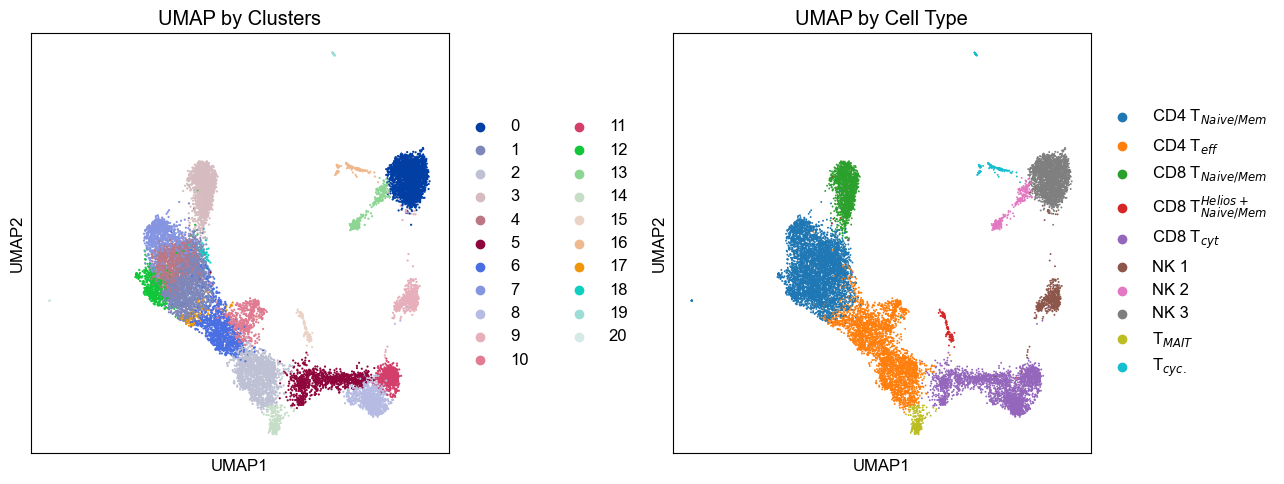

In [44]:
# Set figure size for all plots
sc.settings.figsize = (10, 10)

# Create a figure with multiple subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Plot UMAP with clusters
sc.pl.umap(adata_TNK, color='leiden', ax=ax1, size=10, show=False, title='UMAP by Clusters')

# Plot UMAP with cell types
sc.pl.umap(adata_TNK, color='cell_type_cg', ax=ax2, show=False, title='UMAP by Cell Type')

plt.tight_layout()
plt.show()

plt.close()


### Add fine-graining for selected cell states:

In [45]:
# Create the new column as a regular string column first
adata_TNK.obs['cell_type_sub'] = adata_TNK.obs['cell_type_cg'].astype(str)

# Define cell types to subdivide
fine_grain_states = ['CD4 T$_{eff}$', 'CD8 T$_{cyt}$']

# Process each cell type we want to subdivide
for cell_type in fine_grain_states:
    mask = adata_TNK.obs['cell_type_cg'] == cell_type
    clusters = adata_TNK.obs.loc[mask, 'leiden'].unique()
    # For each cluster, create a new label
    for k, clust in enumerate(clusters):
        cluster_mask = mask & (adata_TNK.obs['leiden'] == clust)
        new_name = f"{cell_type}-{k+1}"
        adata_TNK.obs.loc[cluster_mask, 'cell_type_sub'] = new_name

# Convert to categorical only at the end
adata_TNK.obs['cell_type_sub'] = adata_TNK.obs['cell_type_sub'].astype('category')

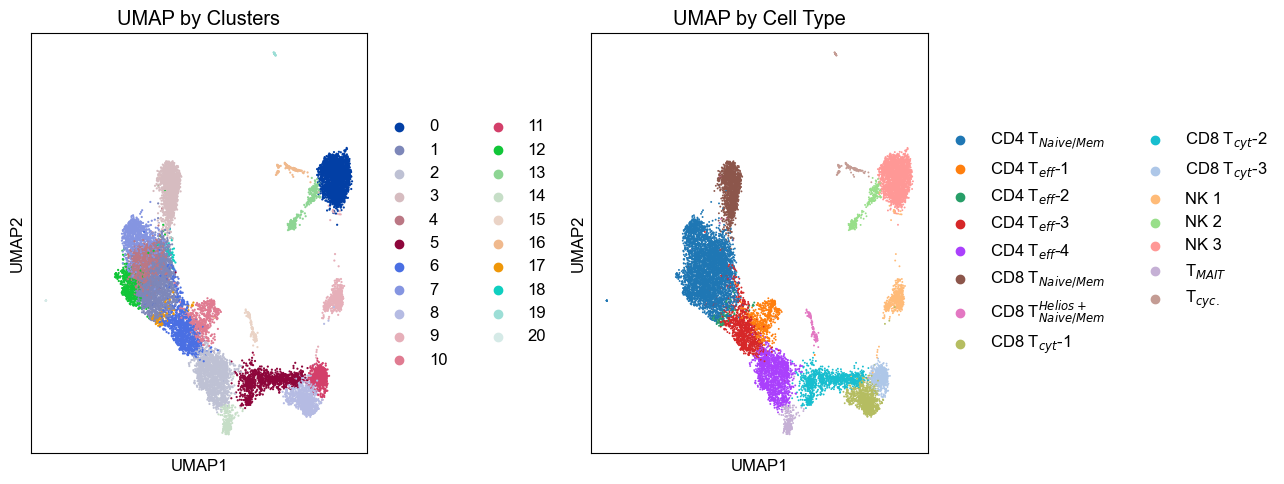

In [46]:
# Set figure size for all plots
sc.settings.figsize = (10, 10)

# Create a figure with multiple subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Plot UMAP with clusters
sc.pl.umap(adata_TNK, color='leiden', ax=ax1, size=10, show=False, title='UMAP by Clusters')

# Plot UMAP with cell types
sc.pl.umap(adata_TNK, color='cell_type_sub', ax=ax2, show=False, title='UMAP by Cell Type')

plt.tight_layout()
plt.show()

plt.close()


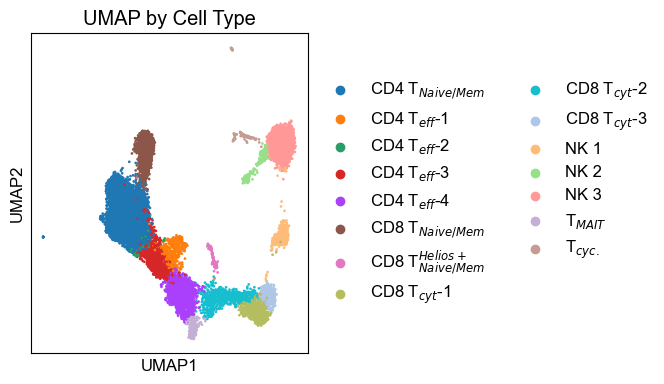

In [47]:
fig, ax1 = plt.subplots(1, 1, figsize=(6.8, 4))
sc.pl.umap(adata_TNK, color='cell_type_sub',size=15, ax=ax1, show=False, title='UMAP by Cell Type')
plt.tight_layout()
#plt.savefig('fig_UMAP_T_NK.pdf')
plt.show()


## Find marker genes for the subsets:

In [49]:
adata_TNK_log = sc.pp.log1p(adata_TNK_unscaled, base=10,copy=True)
adata_TNK_log.obs['cell_type_sub'] = adata_TNK.obs['cell_type_sub']

# Perform ranking for each cell type
sc.tl.rank_genes_groups(
    adata_TNK_log,
    groupby='cell_type_sub',
    method='wilcoxon',  # You can also use 't-test' or other methods
    key_added='cell_type_enriched'
)

# Create a dictionary to store enriched genes for each cell type
enriched_genes = {}

# For each cell type, get significantly enriched genes
for cell_type in adata_TNK.obs['cell_type_sub'].unique():
    # Get the ranked genes for this cell type
    genes = sc.get.rank_genes_groups_df(
        adata_TNK_log, 
        key='cell_type_enriched', 
        group=cell_type
    )
    
    # Filter for significant genes (adjust these thresholds as needed)
    significant_genes = genes[
        (genes['pvals_adj'] < 0.05) &  # adjusted p-value threshold
        (genes['logfoldchanges'] > 1)   # log fold change threshold
    ]
    
    # Store the gene names
    enriched_genes[cell_type] = significant_genes['names'].tolist()
    
    # Print summary for this cell type
    print(f"\n{cell_type}:")
    print(f"Found {len(enriched_genes[cell_type])} enriched genes")
    print("Top 10 genes:", enriched_genes[cell_type][:10])

# Optional: Save the full results
results_df = sc.get.rank_genes_groups_df(
    adata_TNK_log,
    key='cell_type_enriched',
    group=list(adata_TNK.obs['cell_type_sub'].unique())
)


CD4 T$_{Naive/Mem}$:
Found 203 enriched genes
Top 10 genes: ['FHIT', 'LEF1', 'BACH2', 'PRKCA', 'CAMK4', 'FOXP1', 'PLCL1', 'MLLT3', 'SERINC5', 'IGF1R']

CD8 T$_{cyt}$-1:
Found 180 enriched genes
Top 10 genes: ['TGFBR3', 'SYNE1', 'NKG7', 'CCL5', 'ZEB2', 'GZMH', 'AGAP1', 'PPP2R2B', 'RAP1GAP2', 'CD8A']

NK 3:
Found 469 enriched genes
Top 10 genes: ['MCTP2', 'GNLY', 'LINC00299', 'NKG7', 'BNC2', 'ZEB2', 'EPDR1', 'PRF1', 'CTBP2', 'SYNE1']

CD4 T$_{eff}$-1:
Found 142 enriched genes
Top 10 genes: ['PHACTR2', 'STAM', 'CD28', 'TOX', 'LDLRAD4', 'PVT1', 'PELI1', 'TTN', 'CASK', 'ICOS']

CD8 T$_{Naive/Mem}$:
Found 114 enriched genes
Top 10 genes: ['NELL2', 'BACH2', 'PDE3B', 'THEMIS', 'LEF1', 'CD8B', 'SERINC5', 'OXNAD1', 'CCR7', 'FAM117B']

CD8 T$_{cyt}$-2:
Found 72 enriched genes
Top 10 genes: ['CCL5', 'ATXN1', 'KLRC4-KLRK1', 'CD8A', 'AC133644.2', 'MIAT', 'AC004593.2', 'CHN2', 'NIBAN1', 'PPP2R2B']

NK 2:
Found 271 enriched genes
Top 10 genes: ['LINC00299', 'ATP8B4', 'NCAM1', 'GNLY', 'IL12RB2', 'NCAL

In [50]:
# Create a dictionary to store top 5 genes for each cell type
top_genes = {}

# For each cell type, get top 5 genes
for cell_type in adata_TNK_log.obs['cell_type_sub'].unique():
    # Get the ranked genes for this cell type
    genes = sc.get.rank_genes_groups_df(
        adata_TNK_log, 
        key='cell_type_enriched', 
        group=cell_type
    )
    
    # Sort by logfoldchange and get top 5 significant genes
    significant_genes = genes[
        (genes['pvals_adj'] < 0.05) &
        (genes['logfoldchanges'] > 1)
    ].sort_values('logfoldchanges', ascending=False)
    
    # Store top 5 gene names
    top_genes[cell_type] = significant_genes['names'].head(5).tolist()

# Keep track of genes we've seen
seen_genes = set()

# Create a new dictionary with only unique genes
unique_top_genes = {}

# Go through cell types in order
for cell_type in adata_TNK_log.obs['cell_type_sub'].unique():
    gene_list = top_genes[cell_type]
    
    # Filter out any genes we've seen before
    unique_genes = [gene for gene in gene_list if gene not in seen_genes]
    
    # Update our seen genes set
    seen_genes.update(unique_genes)
    
    # Store the unique genes for this cell type
    unique_top_genes[cell_type] = unique_genes

# Replace original dictionary
top_genes = unique_top_genes

**Recent reference defining NK subsets by scRNA-Seq:**
* Reference: https://www.nature.com/articles/s41590-024-01883-0
* The resolution of NK subsets in our data is far sharper than in this paper

**NK 3:**
* These are canonical CD56-dim NK cells
* Key reference: https://pubmed.ncbi.nlm.nih.gov/11698225/
* Considered more mature, based on:
    - CD56dim (NCAM1) lower
    - Express KIRs (e.g. KIR2DL1)
    - Express cytotoxic genes (GZMB, PRF1)
    - Express higher levels of the chemokine receptor CX3CR1
    - Lower Sellectin (SELL)
    - Higher CD57 (B3GAT1)
    - CD16+ (but not brightest) cells

**NK 2:**
* This profile matches quite well with CD56bright NK cells
* Key reference: https://pubmed.ncbi.nlm.nih.gov/11698225/
* Properties:
    * Very high NCAM1
    * Also express: SELL
    * Lower expression of KIRs (KIR2DL1)

**NK 1:**
* This population appears to be what's called "memory" NK cells
    * https://www.nature.com/articles/nri.2015.9
    * https://pubmed.ncbi.nlm.nih.gov/21825173/ - (NKG2C-high, where this is KLRC2)
* Has mature NK cell markers, shared with NK3 (GZMB, PRF1, FCGR3A, CX3CR1, B3GAT1/CD57)
* Also like NK3, it has lower CD56 (NCAM1) and lower NCR1 relative to NK2
* Expresses KLRC2 (NKG2C) - this is a defining feature of adaptive NK cells ??
* Also express: ZBTB38

In [51]:
# Generate renamed adata and save it, to pass back to PBMC_plotting in a different notebook
# Your dictionary with the replacements
renaming_dict = {
    'NK 2': 'NK$_{CD56-hi}$',
    'NK 1': 'NK$_{Mem}$',
    'NK 3': 'NK$_{CD56-lo}$'
}

# Replace only the specified values using map with a lambda function
adata_TNK.obs['cell_type_sub'] = adata_TNK.obs['cell_type_sub'].map(lambda x: renaming_dict.get(x, x))

#adata.write_h5ad('adata_TNK_processed.h5ad')